# Representing a Hypothetical Graph

> To implement a visible neural network we need to process a graph to produce a set of sparse matrieces that represent the same structure and the computations of each node. 

In [ ]:
from sparsevnn.core import *
import torch
from torch import nn
import numpy as np
import plotly.express as px

We'll begin by defining a hypothetical graph. This ultimately will come from a biological system but for now we'll arbitrarily define it.

In [ ]:
graph_connections = {
 'A': ['100278565'],
 'B': ['100278565'],
 'C': ['100383860'],
 'D': ['B', 'C'],
 'y_hat': ['A', 'C', 'D']}

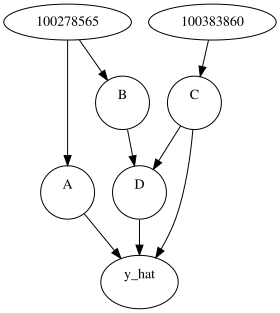

In [ ]:
dict_to_digraph(edge_dict = graph_connections)

Now using the `VNNHelper` we build a lookup dictionary to go from the name for a gene to the location in the vals list. 

In [ ]:
# initialize helper for input nodes
myvnn = VNNHelper(edge_dict = graph_connections)

myvnn.nodes_inp[0:10]

# Get a mapping of brite names to tensor list index
find_names = myvnn.nodes_inp # e.g. ['100383860', '100278565', ... ]

# Calculate the input sizes for each node in the graph. 
# ---

# make up some data to use
ACGT_gene_slice_list = [torch.rand([64, 3, 4]) for e in myvnn.nodes_inp]

# map node names to postions
lookup_dict = dict(zip(myvnn.nodes_inp, [i for i in range(len(ACGT_gene_slice_list))]))

# Get the input sizes for the graph
size_in_zip = zip(myvnn.nodes_inp, [np.prod(ACGT_gene_slice_list[lookup_dict[e]].shape[1:]) for e  in myvnn.nodes_inp])

# Get the input sizes for the graph
size_in_zip = zip(myvnn.nodes_inp, [np.prod(ACGT_gene_slice_list[lookup_dict[e]].shape[1:]) for e  in myvnn.nodes_inp])

In [ ]:
default_out_nodes_inp  = 2
default_out_nodes_edge = 3
default_out_nodes_out  = 1

default_reps_nodes_inp  = 1
default_reps_nodes_edge = 1
default_reps_nodes_out  = 1

default_drop_nodes_inp  = 0.
default_drop_nodes_edge = 0.5
default_drop_nodes_out  = 0.

Now that information gets used to set the input sizes for each node and then set up the other attributes of each of the nodes.

In [ ]:
# init input node sizes
myvnn.set_node_props(key = 'inp', node_val_zip = size_in_zip)

# init node output sizes
myvnn.set_node_props(key = 'out', node_val_zip = zip(myvnn.nodes_inp, [default_out_nodes_inp  for e in myvnn.nodes_inp]))
myvnn.set_node_props(key = 'out', node_val_zip = zip(myvnn.nodes_edge,[default_out_nodes_edge for e in myvnn.nodes_edge]))
myvnn.set_node_props(key = 'out', node_val_zip = zip(myvnn.nodes_out, [default_out_nodes_out  for e in myvnn.nodes_out]))

# # options should be controlled by node_props
myvnn.set_node_props(key = 'flatten', node_val_zip = zip(
    myvnn.nodes_inp, 
    [True for e in myvnn.nodes_inp]))

myvnn.set_node_props(key = 'reps', node_val_zip = zip(myvnn.nodes_inp, [default_reps_nodes_inp  for e in myvnn.nodes_inp]))
myvnn.set_node_props(key = 'reps', node_val_zip = zip(myvnn.nodes_edge,[default_reps_nodes_edge for e in myvnn.nodes_edge]))
myvnn.set_node_props(key = 'reps', node_val_zip = zip(myvnn.nodes_out, [default_reps_nodes_out  for e in myvnn.nodes_out]))

myvnn.set_node_props(key = 'drop', node_val_zip = zip(myvnn.nodes_inp, [default_drop_nodes_inp  for e in myvnn.nodes_inp]))
myvnn.set_node_props(key = 'drop', node_val_zip = zip(myvnn.nodes_edge,[default_drop_nodes_edge for e in myvnn.nodes_edge]))
myvnn.set_node_props(key = 'drop', node_val_zip = zip(myvnn.nodes_out, [default_drop_nodes_out  for e in myvnn.nodes_out]))

myvnn.calc_edge_inp()

In [ ]:
# restrict to the tensors that will be used
vals = [ACGT_gene_slice_list[lookup_dict[i]] for i in myvnn.nodes_inp]

In [ ]:
# replace lookup so that it matches the lenght of the input tensors
new_lookup_dict = {}
for i in range(len(myvnn.nodes_inp)):
    new_lookup_dict[myvnn.nodes_inp[i]] = i

### Calculate nodes membership in each matrix and positions within each

In [ ]:
node_props = myvnn.node_props
edge_dict = myvnn.edge_dict
dependancy_order = myvnn.dependancy_order
node_to_inp_num_dict = new_lookup_dict

In [ ]:
# Take a pass through the dependency order and check that each node comes after all of its dependanies.

# check dep order
tally = []
for d in dependancy_order:
    if edge_dict[d] == []:
        tally.append(d)
    elif False not in [True if e in tally else False for e in edge_dict[d]]:
        tally.append(d)
    else:
        print('error!')
        break

In [ ]:
# Now go through each of the nodes and create chunks containing all the nodes that _do not depend_ on any other nodes in the current chunk. 

#            - A -------
#           /           \
# 100278565 -- B -- D -- y_hat
#                  /    /
# 100383860 -> C -------

#     ['100278565', '100383860',      'C', 'B', 'D', 'A', 'y_hat'] # Example: `dependancy_order` 
# {0: ['100278565', '100383860'], 1: ['C', 'B', 'A'], 2: ['D'], 3: ['y_hat']} # Example: `d_out`

# build output nodes 
d_out = {0:[]}
for d in dependancy_order:
    if edge_dict[d] == []:
        d_out[min(d_out.keys())].append(d)
    else:
        # print((d, edge_dict[d]))

        d_out_i = 1+max(sum([[key for key in d_out.keys() if e in d_out[key]]
                   for e in edge_dict[d]], []))
        
        if d_out_i not in d_out.keys():
            d_out[d_out_i] = []
        d_out[d_out_i].append(d)

In [ ]:
# {3: ['C', 'A'], 2: [], 1: []}

# build index of dependencies that are not calculated in the previous set
d_eye = {}
tally = []
for i in range(max(d_out.keys()), min(d_out.keys()), -1):
    # print(i)
    nodes_needed = sum([edge_dict[e] for e in d_out[i]], [])+tally
    # check against what is there and then dedupe
    nodes_needed = [e for e in nodes_needed if e not in d_out[i-1]]
    nodes_needed = list(set(nodes_needed))
    tally = nodes_needed
    d_eye[i] = nodes_needed
    
# [len(d_eye[i]) for i in d_eye.keys()]

In [ ]:
# build an index of the set of nodes and which values are in the inputs, outputs, or outputs that are not calcuated in this set. 

# {3: {'out': ['y_hat'],                  'inp': ['D'],                      'eye': ['C', 'A']},
#  2: {'out': ['D'],                      'inp': ['C', 'B', 'A'],            'eye': []},
#  1: {'out': ['C', 'B', 'A'],            'inp': ['100278565', '100383860'], 'eye': []},
#  0: {'out': ['100278565', '100383860'], 'inp': ['100278565', '100383860'], 'eye': []}}

dd = {}
for i in d_eye.keys():
    dd[i] = {'out': d_out[i],
             'inp': d_out[i-1],
             'eye': d_eye[i]}
    
# plus special 0 layer that handles the snps
dd[0] = {'out': d_out[0],
         'inp': d_out[0],
         'eye': []}

In [ ]:
# check that the output nodes' inputs are satisfied by the same layer's inputs (inp and eye)

for i in dd.keys():
    # out node in each
    for e in dd[i]['out']:
        # node depends in inp/eye
        node_pass_list = [True if ee in dd[i]['inp']+dd[i]['eye'] else False 
                          for ee in edge_dict[e]]
        if False not in node_pass_list:
            pass
        else:
            print('exit') 

In [ ]:
# Print out information about the size of the weight matrices.
print("Layer\t#In\t#Out")
for i in range(min(dd.keys()), max(dd.keys())+1, 1):
    node_in      = [node_props[e]['out'] for e in dd[i]['inp']+dd[i  ]['eye'] ]
    if i == max(dd.keys()):
        node_out = [node_props[e]['out'] for e in dd[i]['out'] ]
    else:
        node_out = [node_props[e]['out'] for e in dd[i]['out']+dd[i+1]['eye']]
    print(f'{i}:\t{sum(node_in)}\t{sum(node_out)}')

Layer	#In	#Out
0:	4	4
1:	4	9
2:	9	9
3:	9	1


In [ ]:
# wrapper to make description dictionary

dd = mk_NodeGroups(edge_dict = myvnn.edge_dict, 
                   dependancy_order = myvnn.dependancy_order)
dd

{3: {'out': ['y_hat'], 'inp': ['D'], 'eye': ['C', 'A']},
 2: {'out': ['D'], 'inp': ['C', 'B', 'A'], 'eye': []},
 1: {'out': ['C', 'B', 'A'], 'inp': ['100383860', '100278565'], 'eye': []},
 0: {'out': ['100383860', '100278565'],
  'inp': ['100383860', '100278565'],
  'eye': []}}

### Creating Structured Matrices for Layers

In [ ]:
i = 2
px.imshow(structured_layer_info(i, dd, node_props, edge_dict, as_sparse = False).weight)

In [ ]:
# node_props = myvnn.node_props
    # Linear_block = Linear_block_reps,
# edge_dict = myvnn.edge_dict
# dependancy_order = myvnn.dependancy_order
node_to_inp_num_dict = new_lookup_dict


dd = mk_NodeGroups(edge_dict = myvnn.edge_dict, 
                   dependancy_order = myvnn.dependancy_order)

M_list = [structured_layer_info(i = ii, node_groups = dd, node_props= node_props, edge_dict = edge_dict, as_sparse=True) for ii in range(0, max(dd.keys())+1)]

In [ ]:
[e.weight.shape for e in M_list]

[torch.Size([4, 24]),
 torch.Size([9, 4]),
 torch.Size([9, 9]),
 torch.Size([1, 9])]

### Setup Dataloader using `M_list`

In [ ]:
# restrict to the tensors that will be used
vals = torch.concat([vals[lookup_dict[i]].reshape(64, -1) 
                     for i in M_list[0].row_inp
                     ], axis = 1)

In [ ]:
class NeuralNetwork(nn.Module):
    def __init__(self, layer_list):
        super(NeuralNetwork, self).__init__()
        self.layer_list = nn.ModuleList(layer_list)
 
    def forward(self, x):
        for l in self.layer_list:
            x = l(x)
        return x

Builing the model with dropout (3 options)
1. no dropout

In [ ]:
layer_list = []
for i in range(len(M_list)):
    l = SparseLinearCustom(
        M_list[i].weight.shape[1], # have to transpose this?
        M_list[i].weight.shape[0],
        connectivity   = torch.LongTensor(M_list[i].weight.coalesce().indices()),
        custom_weights = M_list[i].weight.coalesce().values(), 
        custom_bias    = M_list[i].bias.clone().detach(), 
        weight_grad_bool = M_list[i].weight_grad_bool, 
        bias_grad_bool   = M_list[i].bias_grad_bool, #.to_sparse()#.indices()
        dropout_p        = None
        )

    layer_list += [l]
    
    if i+1 != len(M_list):
        layer_list += [nn.ReLU()]



model = NeuralNetwork(layer_list)
model(vals)[0:2]

tensor([[-0.4605],
        [-0.4517]], grad_fn=<SliceBackward0>)

2. Uniform dropout (on entries with gradient allowed)

In [ ]:
layer_list = []
for i in range(len(M_list)):
    l = SparseLinearCustom(
        M_list[i].weight.shape[1], # have to transpose this?
        M_list[i].weight.shape[0],
        connectivity   = torch.LongTensor(M_list[i].weight.coalesce().indices()),
        custom_weights = M_list[i].weight.coalesce().values(), 
        custom_bias    = M_list[i].bias.clone().detach(), 
        weight_grad_bool = M_list[i].weight_grad_bool, 
        bias_grad_bool   = M_list[i].bias_grad_bool, #.to_sparse()#.indices()
        dropout_p        = 0.1
        )

    layer_list += [l]
    
    if i+1 != len(M_list):
        layer_list += [nn.ReLU()]



model = NeuralNetwork(layer_list)
model(vals)[0:2]

tensor([[-0.4605],
        [-0.4517]], grad_fn=<SliceBackward0>)

3. Fully customized (node wise)

In [ ]:
layer_list = []
for i in range(len(M_list)):
    l = SparseLinearCustom(
        M_list[i].weight.shape[1], # have to transpose this?
        M_list[i].weight.shape[0],
        connectivity   = torch.LongTensor(M_list[i].weight.coalesce().indices()),
        custom_weights = M_list[i].weight.coalesce().values(), 
        custom_bias    = M_list[i].bias.clone().detach(), 
        weight_grad_bool = M_list[i].weight_grad_bool, 
        bias_grad_bool   = M_list[i].bias_grad_bool, #.to_sparse()#.indices()
        dropout_p        = M_list[i].dropout_p
        )

    layer_list += [l]
    
    if i+1 != len(M_list):
        layer_list += [nn.ReLU()]



model = NeuralNetwork(layer_list)
model(vals)[0:2]

tensor([[-0.2511],
        [-0.1458]], grad_fn=<SliceBackward0>)

In [ ]:
px.imshow(model.layer_list[4].weight.cpu().to_dense().detach().numpy())

In [ ]:
px.imshow(model.layer_list[4].bias.cpu().to_dense().detach().numpy()[:, None])

In [ ]:
before_training = model.layer_list[4].weight.cpu().to_dense().detach().numpy().copy()

In [ ]:
# y_i, xs_i = next(iter(training_dataloader))
y_i, xs_i = torch.rand(vals.shape[0], 1), vals


optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)
loss_fn = nn.MSELoss()

for i in range(1000):
    loss = loss_fn(model(xs_i), y_i)

    optimizer.zero_grad()
    loss.backward()
    # zero select gradients

    for l in model.layer_list:
        if isinstance(l, SparseLinearCustom):
            if l.weight_grad_bool != None:
                # Learnable weight bool: turn 2/1 weight/eye into 0/1
                l.weights.grad = l.weights.grad * (-1 + l.weight_grad_bool.coalesce().values())

            if l.weight_grad_bool != None:
                l.bias.grad    = l.bias.grad    * (-1 + l.bias_grad_bool)

    # break
    optimizer.step()
    if i % 100 == 0:
        print(loss)

tensor(0.8648, grad_fn=<MseLossBackward0>)
tensor(0.0923, grad_fn=<MseLossBackward0>)
tensor(0.0853, grad_fn=<MseLossBackward0>)
tensor(0.0815, grad_fn=<MseLossBackward0>)
tensor(0.0833, grad_fn=<MseLossBackward0>)
tensor(0.0819, grad_fn=<MseLossBackward0>)
tensor(0.0803, grad_fn=<MseLossBackward0>)
tensor(0.0745, grad_fn=<MseLossBackward0>)
tensor(0.0825, grad_fn=<MseLossBackward0>)
tensor(0.0839, grad_fn=<MseLossBackward0>)


In [ ]:
after_training = model.layer_list[4].weight.cpu().to_dense().detach().numpy().copy()

In [ ]:
px.imshow(after_training - before_training)


In [ ]:
px.imshow(model.layer_list[4].weight.cpu().to_dense().detach().numpy())

In [ ]:
px.imshow(model.layer_list[4].bias.cpu().to_dense().detach().numpy()[:, None])

In [ ]:
model.layer_list[2].dropout_p

Parameter containing:
tensor([0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000])

Now let's check if dropout is working. I'll run the first two linear layers of the model twice, then plot the difference of the output matricies. If dropout is working then some of these values should be different between the two runs.

In [ ]:
# make sure it is in training mode. 
model.train()
print(f'model is in '+['training' if e else 'eval' for e in [model.training]][0]+' mode')

out = []
for i in range(2):
    x = model.layer_list[0](xs_i)
    x = model.layer_list[1](x) # relu
    x = model.layer_list[2](x)
    out += [x.detach().to('cpu').numpy()]

out = (out[0]-out[1])
print(f'Max difference is {out.max()}')
px.imshow(out[0:10, :])

model is in training mode
Max difference is 1.841604471206665


Looks like it's working. 

Finally let's verify that this doesn't happen in evaluation mode. 

In [ ]:
model.eval()
print(f'model is in '+['training' if e else 'eval' for e in [model.training]][0]+' mode')

out = []
for i in range(2):
    x = model.layer_list[0](xs_i)
    x = model.layer_list[1](x) # relu
    x = model.layer_list[2](x)
    out += [x.detach().to('cpu').numpy()]

out = (out[0]-out[1])
print(f'Max difference is {out.max()}')
px.imshow(out[0:10, :])

model is in eval mode
Max difference is 0.0


It's not perfect but we're getting _miniscule_ differences so we're likely looking at a rounding/ floating point artifact here. 